## Load RFM Dataset

전처리 단계에서 생성한 고객 단위 RFM 데이터를 불러온다.
이 데이터를 이용하여 고객 세분화를 위한 클러스터링 분석을 진행하도록 한다.

In [1]:
import pandas as pd

rfm = pd.read_csv("../data/processed/rfm_features.csv", index_col = 0)
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,0.693147,11.253955
12347.0,2,2.079442,8.368925
12348.0,75,1.609438,7.494564
12349.0,19,0.693147,7.472245
12350.0,310,0.693147,5.815324


## Feature Scaling

RFM 변수는 서로 다른 스케일을 가지고 있기 때문에 클러스터링 성능 향상을 위해 StandardScaler를 적용한다.

In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

## Elbow Method

최적의 클러스터 개수를 찾기 위해 Elbow Method를 사용한다.

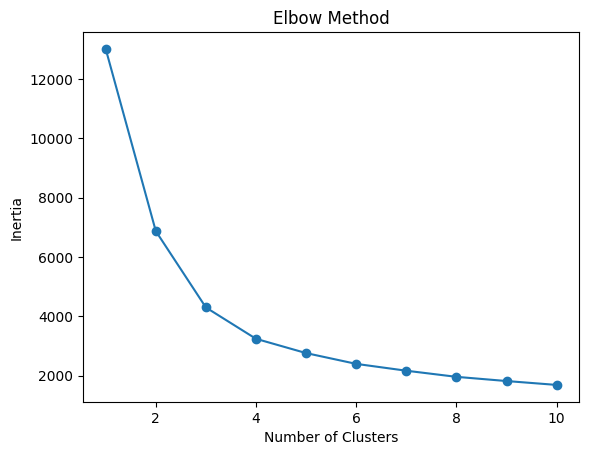

In [3]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker = "o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

## Silhouette Score

클러스터 품질을 평가하기 위해 Silhouette Score를 계산한다.

In [4]:
from sklearn.metrics import silhouette_score

for k in range(2, 11):
    kmeans = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    print("k =", k, "silhouette score =", score)

k = 2 silhouette score = 0.4063902704221693
k = 3 silhouette score = 0.4156459171082181
k = 4 silhouette score = 0.380496895821998
k = 5 silhouette score = 0.34333088434805936
k = 6 silhouette score = 0.33066512722006436
k = 7 silhouette score = 0.29983356620433044
k = 8 silhouette score = 0.3005097272284806
k = 9 silhouette score = 0.28126227614124805
k = 10 silhouette score = 0.2824504762029832


### Optimal Number of Clusters

Elbow Method 결과 k=3부터 k=4 구간에서 inertia 감소가 완만해지는 것을 확인할 수 있다.

Silhouette Score는 k=3에서 가장 높은 값을 보였지만, k=4 또한 비교적 높은 값을 유지하였다.

고객 세분화의 해석 가능성을 고려하여 최종 클러스터 개수를 **4개로 설정하였다.**
- 전자상거래 RFM segmentation에서 보통 아래와 같은 4 segments 구조를 사용한다.
    - VIP 고객
    - 충성 고객
    - 일반 고객
    - 이탈 위험 고객

In [5]:
kmeans = KMeans(n_clusters = 4, random_state = 42, n_init = 10)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,0.693147,11.253955,0
12347.0,2,2.079442,8.368925,3
12348.0,75,1.609438,7.494564,0
12349.0,19,0.693147,7.472245,0
12350.0,310,0.693147,5.815324,2


In [6]:
rfm["Cluster"].value_counts()

Cluster
0    1447
1    1392
2     941
3     558
Name: count, dtype: int64

In [7]:
rfm.groupby("Cluster")[["Recency","Frequency","Monetary"]].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,45.418798,1.613154,7.231227
1,58.139368,0.892787,5.765661
2,259.183847,0.830351,5.636265
3,19.498208,2.650149,8.620148


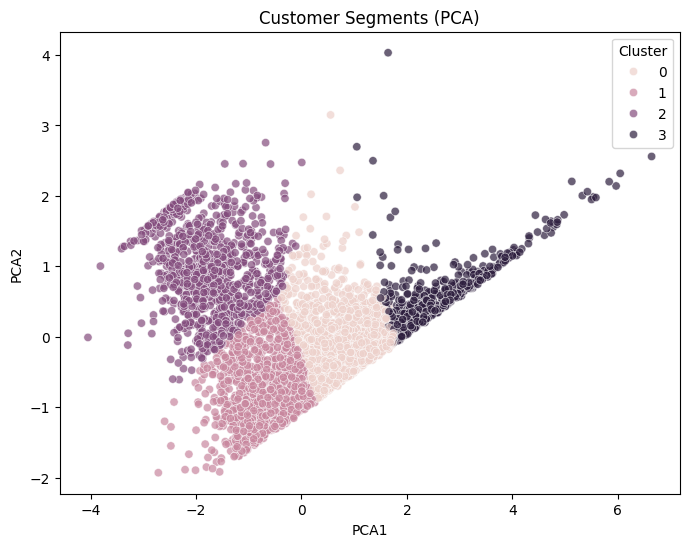

In [8]:
from sklearn.decomposition import PCA
import seaborn as sns

pca = PCA(n_components = 2)

rfm_pca = pca.fit_transform(rfm_scaled)

rfm["PCA1"] = rfm_pca[:,0]
rfm["PCA2"] = rfm_pca[:,1]

plt.figure(figsize = (8, 6))
sns.scatterplot(data = rfm, x = "PCA1", y = "PCA2", hue = "Cluster", alpha = 0.7)
plt.title("Customer Segments (PCA)")
plt.savefig("../figures/cluster_pca.png", dpi = 300, bbox_inches = "tight")
plt.show()

## Customer Segment Interpretation

클러스터별 RFM 평균값을 기반으로 고객 세그먼트를 다음과 같이 해석할 수 있다.

### Cluster 3 – VIP Customers
- Recency가 낮고 Frequency와 Monetary가 가장 높은 고객 그룹
- 최근에도 활발히 구매하며 높은 매출을 발생시키는 핵심 고객

### Cluster 0 – Loyal Customers
- 비교적 최근 구매 이력이 있으며 중간 수준의 구매 빈도와 금액을 보이는 고객
- 안정적인 매출을 만들어내는 충성 고객층

### Cluster 1 – Occasional Customers
- 구매 빈도와 구매 금액이 낮은 고객
- 가끔 구매하는 고객으로 마케팅 프로모션을 통한 재구매 유도가 필요

### Cluster 2 – At-Risk Customers
- Recency가 매우 높아 오랫동안 구매하지 않은 고객
- 고객 이탈 가능성이 높은 그룹

### Cluster Profile (Scaled RFM)

클러스터 간 RFM 특성을 비교하기 위해 변수 스케일 차이를 제거한 표준화된 RFM 값을 사용하여 시각화하였다.

In [9]:
cluster_profile = rfm.groupby("Cluster")[["Recency","Frequency","Monetary"]].mean()

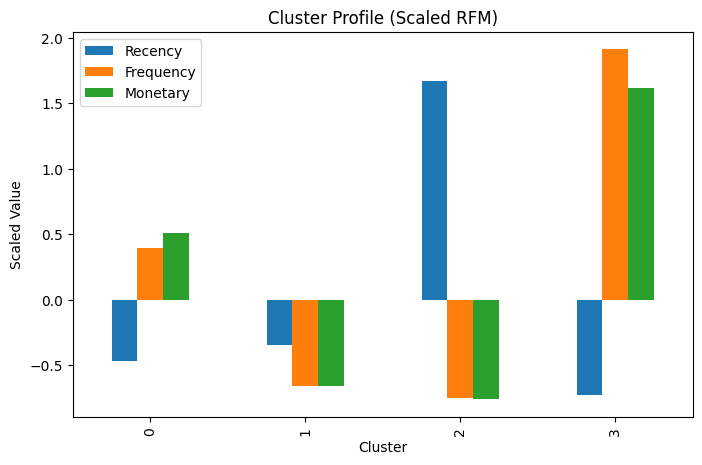

In [10]:
cluster_profile_scaled = pd.DataFrame(scaler.transform(cluster_profile),
                                      columns = cluster_profile.columns,
                                      index = cluster_profile.index)

cluster_profile_scaled.plot(kind = "bar", figsize = (8, 5))
plt.title("Cluster Profile (Scaled RFM)")
plt.ylabel("Scaled Value")
plt.savefig("../figures/cluster_profile.png", dpi = 300, bbox_inches = "tight")
plt.show()

### Cluster Profile Interpretation

- 표준화된 RFM 값을 기준으로 클러스터별 특성을 비교한 결과, Cluster 3은 Frequency와 Monetary가 가장 높고 Recency가 낮아
가장 가치가 높은 VIP 고객군으로 해석할 수 있다.

- 반면 Cluster 2는 Recency가 매우 높고 Frequency와 Monetary가 낮아 오랫동안 구매하지 않은 이탈 위험 고객군으로 볼 수 있다.

- Cluster 0은 비교적 안정적인 구매 패턴을 보이는 충성 고객군, Cluster 1은 구매 빈도와 금액이 낮은 일반 고객군으로 해석된다.

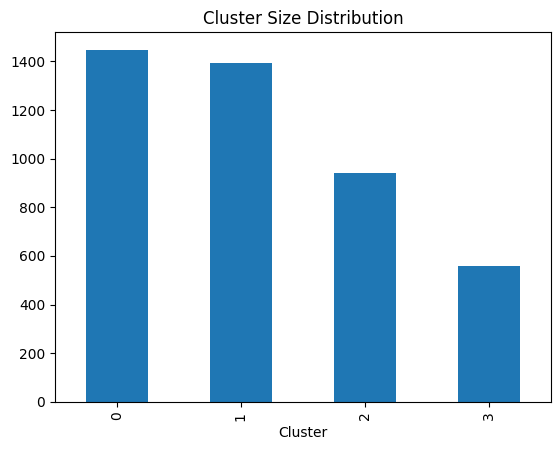

In [11]:
rfm["Cluster"].value_counts().plot(kind = "bar")
plt.title("Cluster Size Distribution")
plt.show()

### Cluster Size Distribution

- 클러스터별 고객 수를 확인한 결과, Cluster 0과 Cluster 1이 전체 고객의 가장 큰 비중을 차지하였다.

- 반면 Cluster 3은 상대적으로 규모는 작지만 구매 빈도와 구매 금액이 높은 핵심 고객군으로 확인되었다.

- 이를 통해 고객 규모와 고객 가치가 반드시 비례하지 않음을 확인할 수 있다.

## Summary

RFM 기반 고객 세분화를 위해 K-means 클러스터링을 적용하였다.
Elbow Method와 Silhouette Score를 통해 적절한 클러스터 수를 탐색한 결과, 고객 세그먼트를 해석하기 용이한 4개의 클러스터를 최종 선택하였다.
클러스터 분석 결과 고객은 다음과 같은 네 가지 그룹으로 구분되었다.

- VIP Customers
- Loyal Customers
- Occasional Customers
- At-Risk Customers

이를 통해 고객 행동 패턴을 기반으로 한 데이터 기반 고객 세분화가 가능함을 확인하였다.